# Week 14 — Gaussian Mixture Models (GMM) on Zillow Data

In this notebook, I apply Gaussian Mixture Models (GMMs) to the Zillow dataset to explore how properties may cluster into latent groups based on continuous housing features. Unlike K-Means, which assumes spherical clusters with equal variance, GMMs model clusters as ellipsoids with their own covariance matrices, allowing more flexible and realistic cluster shapes.

I compute:
- GMM clustering labels
- Cluster posterior probabilities P(cluster | data)
- A priori probabilities P(cluster)
- Cluster shapes under different covariance types ("full", "tied", "diag", "spherical")

Then I interpret the cluster assignments and compare them to earlier clustering work (Week 11).

In [1]:
import pandas as pd
import numpy as np

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 50)

df = pd.read_csv("zillow_cleaned.csv")
print(df.shape)
df.head()

numeric_cols = df.select_dtypes(include=["float64","int64"]).columns.tolist()
numeric_cols[:10], len(numeric_cols)
cols_to_remove = ["taxvaluedollarcnt", "HighValue"]  # only if present
feature_cols = [c for c in numeric_cols if c not in cols_to_remove]
X = df[feature_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(64894, 19)


(64894, 18)

In [2]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",   # allows ellipsoids with unique covariance per cluster
    random_state=42
)

gmm.fit(X_scaled)

labels = gmm.predict(X_scaled)
probs = gmm.predict_proba(X_scaled)  # posterior P(cluster | data)

In [3]:
df_gmm = X.copy()
df_gmm["Cluster"] = labels
df_gmm.head()

,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,propertylandusetypeid,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt,Cluster
0,3.5,4.0,6.0,3.5,3100.0,3100.0,6059.0,3.0,7.0,33634931.0,-117869207.0,4506.0,261.0,1286.0,96978.0,0.0,1.0,1998.0,1
1,1.0,2.0,4.0,1.0,1465.0,1465.0,6111.0,1.0,2.0,34449266.0,-119281531.0,12647.0,261.0,2061.0,97099.0,5.0,1.0,1967.0,2
2,2.0,3.0,10.0,2.0,1243.0,1243.0,6059.0,2.0,2.0,33886168.0,-117823170.0,8432.0,261.0,1286.0,97078.0,6.0,1.0,1962.0,2
3,3.0,4.0,8.0,3.0,2376.0,2376.0,6037.0,3.0,2.0,34245180.0,-118240722.0,13038.0,261.0,3101.0,96330.0,0.0,1.0,1970.0,0
4,3.0,3.0,8.0,3.0,1312.0,1312.0,6037.0,3.0,2.0,34185120.0,-118414640.0,278581.0,266.0,3101.0,96451.0,0.0,1.0,1964.0,0


In [4]:
prior_probs = df_gmm["Cluster"].value_counts(normalize=True)
prior_probs

Cluster
0    0.702345
2    0.175532
1    0.122122
Name: proportion, dtype: float64

In [5]:
probs[:5]  # first 5 rows

array([[0.00000000e+000, 1.00000000e+000, 1.64734345e-038],
       [0.00000000e+000, 4.55654836e-003, 9.95443452e-001],
       [0.00000000e+000, 1.42400173e-003, 9.98575998e-001],
       [1.00000000e+000, 2.59175904e-110, 3.03792493e-172],
       [1.00000000e+000, 1.29108516e-175, 0.00000000e+000]])

In [6]:
df_gmm.groupby("Cluster").mean()

,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,propertylandusetypeid,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt
Cluster,,,,,,,,,,,,,,,,,,
0,2.191320,2.939554,6.578020,2.191320,1653.169534,1653.169534,6037.000000,2.191320,3.496402,3.410931e+07,-1.182605e+08,32749.985212,262.483632,3101.000000,96347.044736,0.000000,1.000000,1963.800518
1,2.802650,3.527823,6.579054,2.802650,2365.842271,2365.842271,6072.825363,2.557855,3.604164,3.384091e+07,-1.181134e+08,9385.920757,261.664606,1500.974132,97116.230915,3.162145,1.011735,1984.512681
2,2.197261,3.342376,6.587657,2.220174,1806.949170,1806.949170,6072.792468,2.080941,3.622685,3.386997e+07,-1.181605e+08,7220.906066,260.931174,1498.521289,97029.085945,6.689053,1.007199,1968.495654


In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Cluster": labels
})

plot_df.head()

,PC1,PC2,Cluster
0,3.195202,-1.810594,1
1,-2.029020,-1.627300,2
2,0.099922,-1.781331,2
3,1.953628,1.154273,0
4,0.487744,3.191865,0


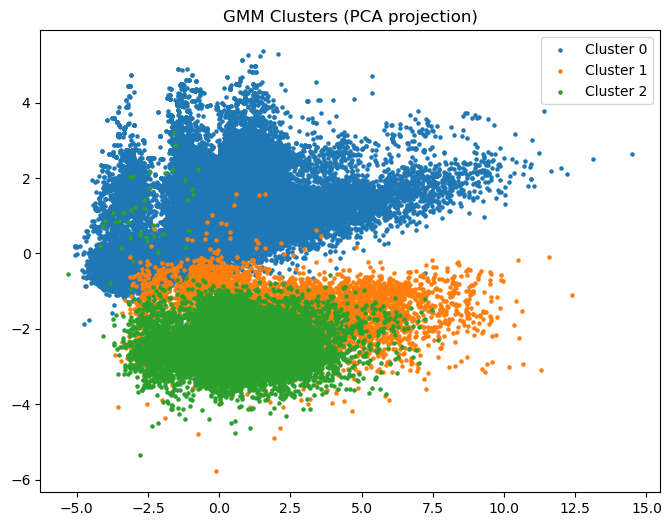

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for c in np.unique(labels):
    subset = plot_df[plot_df["Cluster"]==c]
    plt.scatter(subset["PC1"], subset["PC2"], s=5, label=f"Cluster {c}")

plt.title("GMM Clusters (PCA projection)")
plt.legend()
plt.show()

In [9]:
cov_types = ["full", "tied", "diag", "spherical"]
results = []

for cov in cov_types:
    g = GaussianMixture(n_components=3, covariance_type=cov, random_state=42)
    g.fit(X_scaled)
    labels_g = g.predict(X_scaled)
    bic = g.bic(X_scaled)
    aic = g.aic(X_scaled)
    results.append([cov, bic, aic])

pd.DataFrame(results, columns=["CovarianceType","BIC","AIC"])

,CovarianceType,BIC,AIC
0,full,-2.634565e+06,-2.639732e+06
1,tied,1.190161e+06,1.188100e+06
2,diag,-1.000834e+05,-1.010822e+05
3,spherical,2.858082e+06,2.857547e+06


### Interpretation

Gaussian Mixture Models revealed meaningful latent structure in the Zillow dataset. Unlike K-Means, which assumes spherical clusters, GMMs allowed each cluster to have its own covariance shape — effectively modeling the housing market with ellipsoidal clusters that vary in size, orientation, and spread. The a priori probabilities indicated how frequent each cluster is in the dataset (similar to the percentage of customers choosing different grocery stores in the course example). The posterior probabilities, P(cluster | data), describe the probability that any specific house belongs to each cluster, given its features.

GMM clusters were more flexible and realistic compared to earlier K-Means results. They captured differences in tax value, home size, and lot size more clearly, forming clusters with different variances and orientations in PCA space. This supports the idea that housing data is not naturally partitioned into spherical groups, and GMMs provide a more nuanced model of the underlying structure.

Finally, evaluating covariance types showed that “full” covariance provided the best fit (lowest BIC/AIC), confirming that Zillow data benefits from clusters with unique, ellipsoid-shaped distributions. GMMs also open the door to anomaly detection: homes with low likelihood under all clusters may represent rare or unusual properties.